## SCP/SCA

Use sequential convex approximation to solve probelm using first-order approximation to treat nonconvex optimization

In [ ]:
import cvxpy as cp
import numpy as np

# ============================================================
# Constant settings
# ============================================================
N = 300                  # number of time steps
h = 0.01                 # time step
m = 1.0                 # mass
g = 10                # gravity
I = 0.1                # moment of inertia
r = 0.2                 # arm length / torque coefficient
u_max = 10.0            # max thrust per rotor
max_iters = 200          # SCP iterations
tol = 1e-3              # convergence tolerance

delta_x = 1   # trust region size for state
delta_u = 1.5   # trust region size for control

# State: x = [q1, v1, q2, v2, q3, w]
x0 = np.array([0.25, 0.0, 0.5, 0.0, 0.0, 0.0])
xT = np.array([0.75, 0.0, 1.5, 0.0, 0.0, 0.0])

# ============================================================
# Initial guess
# ============================================================
x_bar = np.zeros((6, N + 1))
u1_bar = 0.6 * u_max * np.ones(N)
u2_bar = 0.6 * u_max * np.ones(N)

x_bar[:, 0] = x0
for k in range(N):
    # simple straight-line initial guess for positions
    alpha = (k + 1) / N
    x_bar[0, k + 1] = (1 - alpha) * x0[0] + alpha * xT[0]
    x_bar[2, k + 1] = (1 - alpha) * x0[2] + alpha * xT[2]
    x_bar[4, k + 1] = (1 - alpha) * x0[4] + alpha * xT[4]
    x_bar[1, k + 1] = (x_bar[0, k + 1] - x_bar[0, k ])/h
    x_bar[3, k + 1] = (x_bar[2, k + 1] - x_bar[2, k ])/h
    x_bar[5, k + 1] = (x_bar[4, k + 1] - x_bar[4, k ])/h

# ============================================================
# SCP loop
# ============================================================
count = 0; #min_cost = np.inf
cost_list = []
for it in range(max_iters):
    # Decision variables
    x = cp.Variable((6, N + 1))
    u1 = cp.Variable(N)
    u2 = cp.Variable(N)

    constraints = []

    # Boundary conditions
    constraints += [x[:, 0] == x0]
    constraints += [x[:, N] == xT]

    # Dynamics linearization constraints
    for k in range(N):
        # Nominal values
        q1b = x_bar[0, k]
        v1b = x_bar[1, k]
        q2b = x_bar[2, k]
        v2b = x_bar[3, k]
        q3b = x_bar[4, k]
        wb  = x_bar[5, k]
        u1b = u1_bar[k]
        u2b = u2_bar[k]

        ub_sum = u1b + u2b
        db = u2b - u1b

        # Current variables
        q1 = x[0, k]
        v1 = x[1, k]
        q2 = x[2, k]
        v2 = x[3, k]
        q3 = x[4, k]
        w  = x[5, k]

        du1 = u1[k] - u1b
        du2 = u2[k] - u2b
        du_sum = du1 + du2
        dq3 = q3 - q3b

        # Linearize the nonlinear terms:
        # sin(q3)*(u1+u2) ≈ sin(q3b)*ub_sum + cos(q3b)*ub_sum*(q3-q3b) + sin(q3b)*( (u1-u1b)+(u2-u2b) )
        sinb = np.sin(q3b)
        cosb = np.cos(q3b)

        sin_term = sinb * ub_sum + cosb * ub_sum * dq3 + sinb * du_sum

        # cos(q3)*(u1+u2) ≈ cos(q3b)*ub_sum - sin(q3b)*ub_sum*(q3-q3b) + cos(q3b)*( (u1-u1b)+(u2-u2b) )
        cos_term = cosb * ub_sum - sinb * ub_sum * dq3 + cosb * du_sum

        # Explicit Euler discretization
        q1_next = q1 + h * v1
        v1_next = v1 + h * (-1.0 / m) * sin_term

        q2_next = q2 + h * v2
        v2_next = v2 + h * ((1.0 / m) * (cos_term - m * g))

        q3_next = q3 + h * w
        w_next  = w + h * (r / I) * (u2[k] - u1[k])

        constraints += [
            x[0, k + 1] == q1_next,
            x[1, k + 1] == v1_next,
            x[2, k + 1] == q2_next,
            x[3, k + 1] == v2_next,
            x[4, k + 1] == q3_next,
            x[5, k + 1] == w_next,
        ]

        constraints += [
        x[:, k] >= x_bar[:, k] - delta_x,
        x[:, k] <= x_bar[:, k] + delta_x,
        ]

        constraints += [
        u1[k] >= u1_bar[k] - delta_u,
        u1[k] <= u1_bar[k] + delta_u,
        u2[k] >= u2_bar[k] - delta_u,
        u2[k] <= u2_bar[k] + delta_u,
        ]   

    constraints += [
        x[:, N] >= x_bar[:, N] - delta_x,
        x[:, N] <= x_bar[:, N] + delta_x,
    ]

    # Control bounds
    constraints += [u1 >= 0, u1 <= u_max]
    constraints += [u2 >= 0, u2 <= u_max]

    # Objective: minimum effort
    objective = cp.Minimize(cp.sum_squares(u1) + cp.sum_squares(u2))

    # Solve convex subproblem
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.OSQP, verbose=False)

    if it == 0:
        min_cost = problem.value

    print(f"Iteration {it+1}: status = {problem.status}, cost = {problem.value}, min cost={min_cost}")

    if problem.status not in ["optimal", "optimal_inaccurate"]:
        print("Solver failed.")
        break
    # Check convergence
    x_new = x.value
    u1_new = u1.value
    u2_new = u2.value

    dx = np.max(np.abs(x_new - x_bar))
    du = max(np.max(np.abs(u1_new - u1_bar)), np.max(np.abs(u2_new - u2_bar)))

    x_bar = x_new.copy()
    u1_bar = u1_new.copy()
    u2_bar = u2_new.copy()

    current_cost = problem.value
    cost_list.append(current_cost)
    if current_cost < min_cost:
        if min_cost - current_cost > 0.01:
            min_cost = current_cost
            count = 0
        else:
            count = count + 1
    else: 
        count = count + 1
    if count >= 10:
        print("Cost Converge")
        break
    
    #if max(dx, du) < tol:
    #    print("Converged.")
    #    break
    

# ============================================================
# Results
# ============================================================
print("\nFinal solution:")
print("x =", x_bar)
print("u1 =", u1_bar)
print("u2 =", u2_bar)

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, figsize=(10,12))

axes[0].grid(True, linestyle='--', alpha=0.6)

axes[0].plot(x_bar[0], label=r"$q_1$")
axes[0].plot(x_bar[1], label=r"$\dot{q_1}$")
axes[0].plot(x_bar[2], label=r"$q_2$")
axes[0].plot(x_bar[3], label=r"$\dot{q_2}$")
axes[0].plot(x_bar[4], label=r"$q_3$")
axes[0].plot(x_bar[5], label=r"$\dot{q_3}$")
axes[0].legend()

axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].plot(u1_bar, label=r"$u_1$")
axes[1].plot(u2_bar, label=r"$u_2$")
axes[1].legend()

axes[2].plot(np.log10(cost_list), label=r"Objective function ($\log_{10}$)")
axes[2].legend()

In [ ]:
from plot_utils import *
import numpy as np

q_traj = np.array([x_bar[0, :], x_bar[2, :],x_bar[4, :]]).T
u_traj = np.array([u1_bar, u2_bar]).T
plot_trajectory(2, 2, {'r': .2}, 
    [{'x': .75, 'uh': .2, 'bh': .6}, 
    {'x': 1.3, 'uh': 0.7, 'bh': 0}], 
    q_traj, 
    u_traj)

## IPOPT

Use interior point optimization built in cvxpy to solve problem

In [5]:
"""
Optimize a planar quadrotor trajectory using cvxpy with IPOPT (nonlinear solver).
`
This script follows the setup in optim_test.ipynb but uses the full nonlinear
discrete dynamics in quadrotor_dynamics.f_discrete and solves the resulting
nonconvex NLP with IPOPT via cvxpy: prob.solve(nlp=True, solver=cp.IPOPT).

Requirements:
- cvxpy built with IPOPT support (cyipopt installed and cvxpy from a recent
  branch that includes IPOPT interface). If IPOPT is not available, the script
  will raise an informative error.

Usage: run as a script. It will print solver status and final trajectory and
controls.
"""
import numpy as np
import cvxpy as cp
from quadrotor_dynamics import f_discrete, m, g, I, r


def solve_quadrotor(x0 = np.array([0.25, 0.0, 0.5, 0.0, 0.0, 0.0]),
                    xT = np.array([0.75, 0.0, 1.5, 0.0, 0.0, 0.0]),
                    obstacles_height = np.array([.2, .6]),  #upper height and lower height of obstacle
                    slack_traj_num = 10,
                    N=100, h=0.01, u_max=10.0,
                    border_x = np.array([0, 4]),
                    border_y = np.array([0,2])):
    # State: x = [q1, v1, q2, v2, q3, w]
    
    # Decision variables
    x = cp.Variable((6, N + 1))
    u1 = cp.Variable(N)
    u2 = cp.Variable(N)

    constraints = []
    constraints += [x[:, 0] == x0]
    constraints += [x[0, N] == xT[0]]

    # Dynamics constraints using the nonlinear discrete dynamics
    for k in range(N):
        xk = x[:, k]
        uk = cp.hstack([u1[k], u2[k]])
        x_next = f_discrete(xk, uk, h)

        constraints += [x[:, k + 1] == x_next]

        constraints += [x[0, k+1] >= border_x[0]]
        constraints += [x[0, k+1] <= border_x[1]]

        constraints += [x[2, k+1] >= border_y[0]]
        constraints += [x[2, k+1] <= border_y[1]]

    # Border avoid constraints
    for k in range(N-slack_traj_num, N):
        constraints += [x[2, k+1] >= obstacles_height[1]]
        constraints += [x[2, k+1] <= border_y[1] - obstacles_height[0]]

    # Control bounds
    constraints += [u1 >= 0, u1 <= u_max]
    constraints += [u2 >= 0, u2 <= u_max]

    # Objective: minimize control effort
    objective = cp.Minimize(cp.sum_squares(u1) + cp.sum_squares(u2))

    problem = cp.Problem(objective, constraints)

    print("Solving with IPOPT (nlp=True, solver=cp.IPOPT). This may take a while...")
    # Solve as a nonlinear program
    try:
        problem.solve(nlp=True, solver=cp.IPOPT, verbose=True)
    except Exception as e:
        raise RuntimeError(
            "IPOPT solve failed. Ensure cyipopt and a compatible cvxpy build are installed. "
            f"Original error: {e}"
        )

    print(f"Status: {problem.status}, Objective: {problem.value}")
    return x.value, u1.value, u2.value, problem


if __name__ == '__main__':
    cost = 0
    x_traj = np.array([]); u1_traj = np.array([]); u2_traj = np.array([])

    _x_traj, _u1_traj, _u2_traj, problem = solve_quadrotor(N=100, h=0.01, u_max=10.0)
    x_traj = _x_traj; u1_traj = _u1_traj; u2_traj = _u2_traj;
    cost += problem.value

    #_x_traj, _u1_traj, _u2_traj, problem = solve_quadrotor(x0=_x_traj[:, -1], xT=[2], N=200, h=0.01, u_max=10.0, obstacles_height=[1.25, 0])
    #x_traj = np.hstack((x_traj, _x_traj)); u1_traj = np.hstack((u1_traj, _u1_traj)); u2_traj = np.hstack((u2_traj, _u2_traj));
    #cost += problem.value


    print("x shape:", x_traj.shape)
    print("u1 shape:", u1_traj.shape)
    print("u2 shape:", u2_traj.shape)


(CVXPY) May 20 07:50:43 PM: Your problem has 806 variables, 1427 constraints, and 0 parameters.
(CVXPY) May 20 07:50:43 PM: It is compliant with the following grammars: 
(CVXPY) May 20 07:50:43 PM: DCP verification time: 0.0003 seconds.
(CVXPY) May 20 07:50:43 PM: Expression tree has 10 nodes.
(CVXPY) May 20 07:50:43 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 20 07:50:43 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 20 07:50:43 PM: Your problem is compiled with the CPP canonicalization backend.


Solving with IPOPT (nlp=True, solver=cp.IPOPT). This may take a while...
                                     CVXPY                                     
                            v1.9.0.dev0+256.9ff523c                            
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:     3507
Number of nonzeros in inequality constraint Jacobian.:      820
Number of nonzeros in Lagrangian Hessian.............:      600

Total number of variables............................:     1406
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:     1207
Total number of inequality constraints...............:      820
        inequality constraints with only lower bounds:      820
   inequality constraints with lower and upper bounds:

### Plot

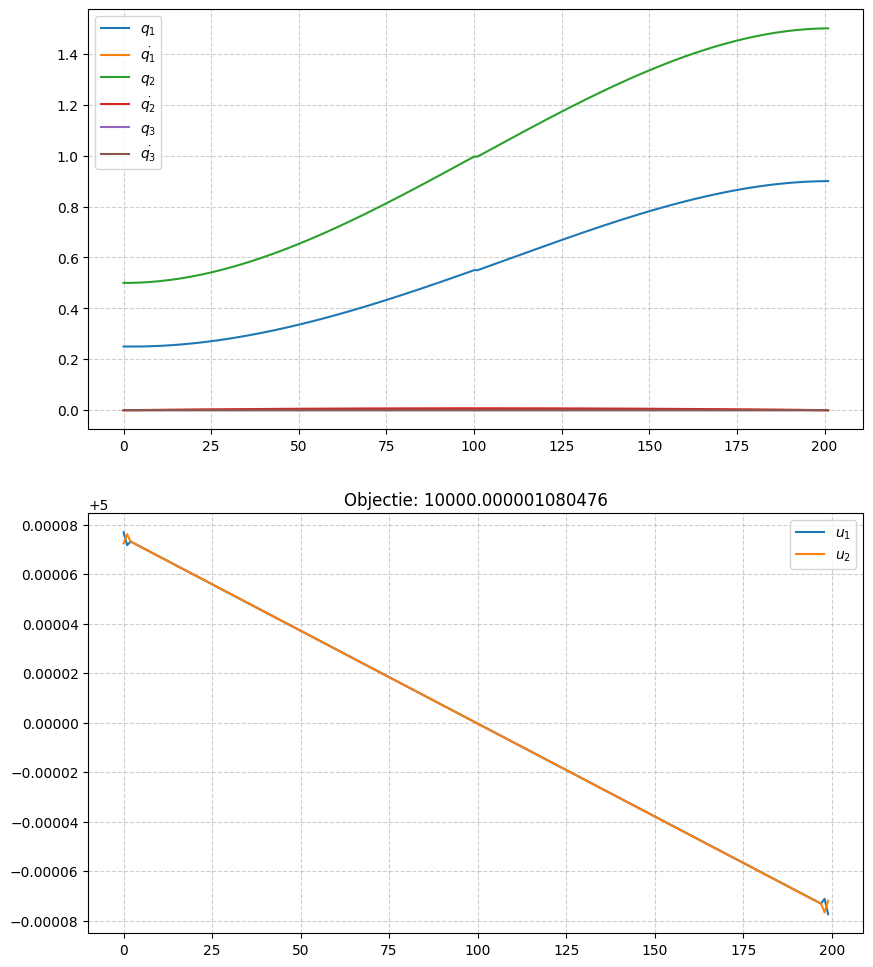

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, figsize=(10,12))

axes[0].grid(True, linestyle='--', alpha=0.6)

axes[0].plot(x_traj[0], label=r"$q_1$")
axes[0].plot(x_traj[1], label=r"$\dot{q_1}$")
axes[0].plot(x_traj[2], label=r"$q_2$")
axes[0].plot(x_traj[3], label=r"$\dot{q_2}$")
axes[0].plot(x_traj[4], label=r"$q_3$")
axes[0].plot(x_traj[5], label=r"$\dot{q_3}$")
axes[0].legend()

axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].plot(u1_traj, label=r"$u_1$")
axes[1].plot(u2_traj, label=r"$u_2$")
plt.title(f"Objectie: {cost}")
axes[1].legend()

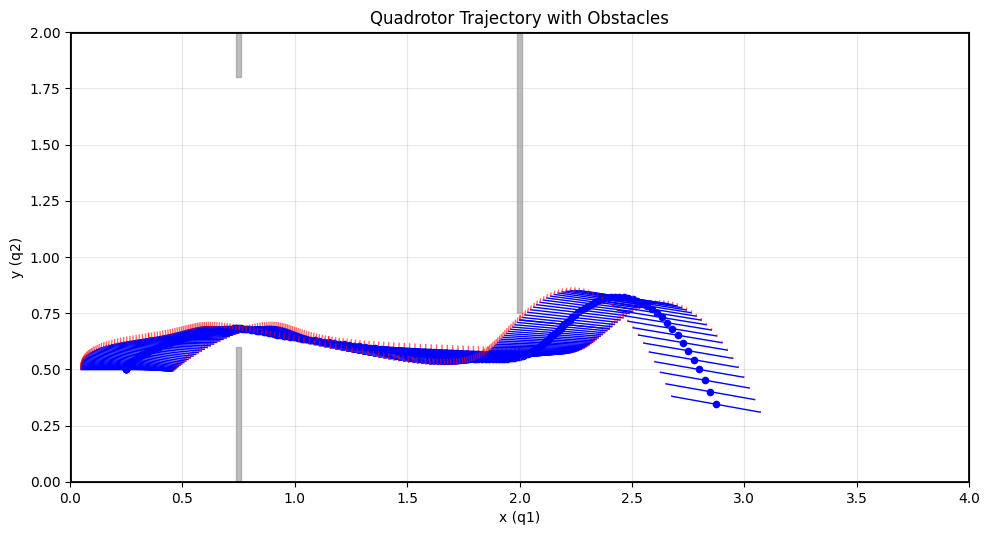

In [7]:
from plot_utils import *
import numpy as np

q_traj = np.array([x_traj[0, :], x_traj[2, :],x_traj[4, :]]).T
u_traj = np.array([u1_traj, u2_traj]).T
plot_trajectory(2, 4, {'r': .2}, 
    [{'x': .75, 'uh': .2, 'bh': .6}, 
    {'x': 2, 'uh': 1.25, 'bh': 0}
    ], 
    q_traj, 
    u_traj)

### Obstacle

In [21]:
[1] * 3

[1, 1, 1]

In [6]:
"""
Optimize a planar quadrotor trajectory using cvxpy with IPOPT (nonlinear solver).
`
This script follows the setup in optim_test.ipynb but uses the full nonlinear
discrete dynamics in quadrotor_dynamics.f_discrete and solves the resulting
nonconvex NLP with IPOPT via cvxpy: prob.solve(nlp=True, solver=cp.IPOPT).

Requirements:
- cvxpy built with IPOPT support (cyipopt installed and cvxpy from a recent
  branch that includes IPOPT interface). If IPOPT is not available, the script
  will raise an informative error.

Usage: run as a script. It will print solver status and final trajectory and
controls.
"""
import numpy as np
import cvxpy as cp
from quadrotor_dynamics import f_discrete, m, g, I, r
from plot_utils import trajectory_decomposition


def solve_quadrotor(x0 = np.array([0.25, 0.0, 0.5, 0.0, 0.0, 0.0]),
                    xT = np.array([2, 0.0, 1.5, 0.0, 0.0, 0.0]),
                    obstacles = None,
                    N=100, u_max=10.0,
                    border_x = np.array([0, 4]),
                    border_y = np.array([0,2]),
                    gate_y_margin=0.05,
                    h_min=5e-5, h_max=5e-1):
    """
    Solve the quadrotor trajectory with segmentation across obstacle gates.

    This version uses a single global control sequence (u1,u2) of length N and
    treats the time step h as a cvxpy decision variable bounded by [h_min,h_max].
    The total number of intervals is N and each segment consumes a slice of the
    global control sequence; segments are assigned roughly equal counts (at
    least 2 intervals each).
    """

    # Prepare obstacles input for decomposition: allow None or list of dicts
    obs_for_decomp = [] if obstacles is None else obstacles

    # Get segments along x using the quadrotor radius r
    segments = trajectory_decomposition(float(x0[0]), float(xT[0]), obs_for_decomp, r)

    # Simple equal allocation of the N intervals across segments
    n_seg = len(segments)
    print(segments)
    if N < 2 * n_seg:
        raise ValueError("N must be at least 2 * number_of_segments")
    base = N // n_seg
    counts = [base] * n_seg
    rem = N - base * n_seg
    for i in range(rem):
        counts[i] += 1

    # Global control sequences
    u1 = cp.Variable(N)
    u2 = cp.Variable(N)

    # Time step h as a decision variable
    h = cp.Variable()

    constraints = []
    # bounds on h to keep problem well posed
    constraints += [h >= float(h_min), h <= float(h_max)]

    # Build per-segment state variables and dynamics using slices of global u
    x_segs = []
    u1_segs = []; u2_segs = []
    idx_offset = 0
    obs_idx = 0
    for si, seg in enumerate(segments):
        Ni = int(counts[si])
        x_seg = cp.Variable((6, Ni + 1))
        x_segs.append(x_seg)

        u1_seg = cp.Variable(N); u2_seg = cp.Variable(N)
        u1_segs.append(u1_seg); u2_segs.append(u2_seg)

        # x bounds for this segment (handle direction)
        xmin = min(seg['x_start'], seg['x_end'])
        xmax = max(seg['x_start'], seg['x_end'])
        constraints += [x_seg[0, :] >= float(xmin), x_seg[0, :] <= float(xmax)]

        # y (q2) bounds: free segments -> canvas height; gate segments -> gate opening
        if seg['kind'] == 'free':
            constraints += [x_seg[2, :] >= float(border_y[0]), x_seg[2, :] <= float(border_y[1])]
        else:
            gate_ymin = obstacles[obs_idx]['bh'] + gate_y_margin
            gate_ymax = border_y[1] - obstacles[obs_idx]['uh'] - gate_y_margin

            constraints += [x_seg[2, :] >= float(gate_ymin), x_seg[2, :] <= float(gate_ymax)]
            obs_idx += 1

        # Dynamics within segment using global u slices
        # physical model transition
        for k in range(Ni):
            global_idx = idx_offset + k
            xk = x_seg[:, k]
            uk = cp.hstack([u1[global_idx], u2[global_idx]])
            x_next = f_discrete(xk, uk, h)
            constraints += [x_seg[:, k + 1] == x_next]

        # Continuity with previous segment
        if si == 0:
            constraints += [x_seg[:, 0] == x0]
        else:
            constraints += [x_seg[:, 0] == x_segs[si - 1][:, -1]]

        # Final segment must match xT at its last state
        if si == len(segments) - 1:
            constraints += [x_seg[0, -1] == float(xT[0])]
        idx_offset += Ni

    # Global control bounds
    constraints += [u1 >= 0, u1 <= u_max]
    constraints += [u2 >= 0, u2 <= u_max]

    # Objective: minimize total control effort across global sequences
    objective = cp.Minimize(cp.sum_squares(u1) + cp.sum_squares(u2))

    problem = cp.Problem(objective, constraints)

    print("Solving with IPOPT (nlp=True, solver=cp.IPOPT). This may take a while...")
    try:
        problem.solve(nlp=True, solver=cp.IPOPT, verbose=True, tol=1e-4)
    except Exception as e:
        raise RuntimeError(
            "IPOPT solve failed. Ensure cyipopt and a compatible cvxpy build are installed. "
            f"Original error: {e}"
        )

    print(f"Status: {problem.status}, Objective: {problem.value}")

    # Collect concatenated trajectories
    x_traj = np.hstack([xs.value for xs in x_segs]) if len(x_segs) > 0 else np.zeros((6, 0))
    u1_traj = u1.value if u1.value is not None else np.zeros(N)
    u2_traj = u2.value if u2.value is not None else np.zeros(N)
    h_val = h.value if h.value is not None else None
    return x_traj, u1_traj, u2_traj, h_val, problem


if __name__ == '__main__':
    cost = 0
    x_traj = np.array([]); u1_traj = np.array([]); u2_traj = np.array([])

    _x_traj, _u1_traj, _u2_traj, _h_val, problem = solve_quadrotor(xT = np.array([3, 0.0, 1.5, 0.0, 0.0, 0.0]), 
        N=200, u_max=10.0, 
        obstacles=[{'x': .75, 'uh': .2, 'bh': .6}, {'x': 2, 'uh': 1.25, 'bh': 0}])
    #[{'x': .75, 'uh': .2, 'bh': .6}, {'x': 2, 'uh': 1.25, 'bh': 0}]
    x_traj = _x_traj; u1_traj = _u1_traj; u2_traj = _u2_traj;
    cost += problem.value

    #_x_traj, _u1_traj, _u2_traj, problem = solve_quadrotor(x0=_x_traj[:, -1], xT=[2], N=200, h=0.01, u_max=10.0, obstacles_height=[1.25, 0])
    #x_traj = np.hstack((x_traj, _x_traj)); u1_traj = np.hstack((u1_traj, _u1_traj)); u2_traj = np.hstack((u2_traj, _u2_traj));
    #cost += problem.value


    print("x shape:", x_traj.shape)
    print("u1 shape:", u1_traj.shape)
    print("u2 shape:", u2_traj.shape)


(CVXPY) May 21 02:30:20 AM: Your problem has 1631 variables, 2853 constraints, and 0 parameters.
(CVXPY) May 21 02:30:20 AM: It is compliant with the following grammars: 
(CVXPY) May 21 02:30:20 AM: DCP verification time: 0.0004 seconds.
(CVXPY) May 21 02:30:20 AM: Expression tree has 10 nodes.
(CVXPY) May 21 02:30:20 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 21 02:30:20 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 21 02:30:20 AM: Your problem is compiled with the CPP canonicalization backend.


[{'x_start': 0.25, 'x_end': 0.55, 'kind': 'free'}, {'x_start': 0.55, 'x_end': 0.95, 'kind': 'gate'}, {'x_start': 0.95, 'x_end': 1.8, 'kind': 'free'}, {'x_start': 1.8, 'x_end': 2.2, 'kind': 'gate'}, {'x_start': 2.2, 'x_end': 3.0, 'kind': 'free'}]
Solving with IPOPT (nlp=True, solver=cp.IPOPT). This may take a while...
                                     CVXPY                                     
                            v1.9.0.dev0+256.9ff523c                            
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:    13055
Number of nonzeros in inequality constraint Jacobian.:     1622
Number of nonzeros in Lagrangian Hessian.............:     2400

Total number of variables............................:     5231
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0


## Obstacle planning
With Lagrangian dual function to convert hard constraints into slack penalty